# Assignment 05: Exploratory Data Analysis & Data Cleaning

Complete EDA and data cleaning for three datasets:
1. **Loan Eligibility Dataset**
2. **Adult Census Income Dataset**
3. **Hotel Booking Dataset**


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


---
# Dataset 1: Loan Eligibility

Loading the loan dataset and performing complete EDA and data cleaning.


In [12]:
loan_df = pd.read_csv('loan-train.csv')
loan_original = loan_df.copy()
print('Shape:', loan_df.shape)
loan_df.head()


Shape: (1614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
loan_df.info()
print('\n--- Data Types ---')
print(loan_df.dtypes)
print('\n--- Statistical Summary (Numerical) ---')
loan_df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1614 non-null   str    
 1   Gender             1601 non-null   str    
 2   Married            1611 non-null   str    
 3   Dependents         1599 non-null   str    
 4   Education          1614 non-null   str    
 5   Self_Employed      1582 non-null   str    
 6   ApplicantIncome    1614 non-null   int64  
 7   CoapplicantIncome  1614 non-null   float64
 8   LoanAmount         1592 non-null   float64
 9   Loan_Amount_Term   1600 non-null   float64
 10  Credit_History     1564 non-null   float64
 11  Property_Area      1614 non-null   str    
 12  Loan_Status        1614 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 164.1 KB

--- Data Types ---
Loan_ID                  str
Gender                   str
Married                  str
Dependents       

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,1614.000000,1614.000000,1592.000000,1600.000000,1564.00000
mean,8746.304833,3658.722999,218.846734,290.475000,0.63555
std,6249.885122,3291.745935,133.623293,81.899735,0.48143
min,150.000000,0.000000,9.000000,12.000000,0.00000
25%,3675.250000,986.250000,112.000000,240.000000,0.00000
50%,7045.000000,2941.500000,180.000000,360.000000,1.00000
75%,13251.000000,5893.000000,324.000000,360.000000,1.00000
max,81000.000000,41667.000000,700.000000,480.000000,1.00000


In [ ]:
print('--- Statistical Summary (Categorical) ---')
loan_df.describe(include='object')


## Missing Values Analysis


In [14]:
missing_loan = loan_df.isnull().sum()
missing_pct_loan = (missing_loan / len(loan_df) * 100).round(2)
missing_df_loan = pd.DataFrame({'Missing Count': missing_loan, 'Missing %': missing_pct_loan})
missing_df_loan[missing_df_loan['Missing Count'] > 0]


,Missing Count,Missing %
Gender,13,0.81
Married,3,0.19
Dependents,15,0.93
Self_Employed,32,1.98
LoanAmount,22,1.36
Loan_Amount_Term,14,0.87
Credit_History,50,3.10


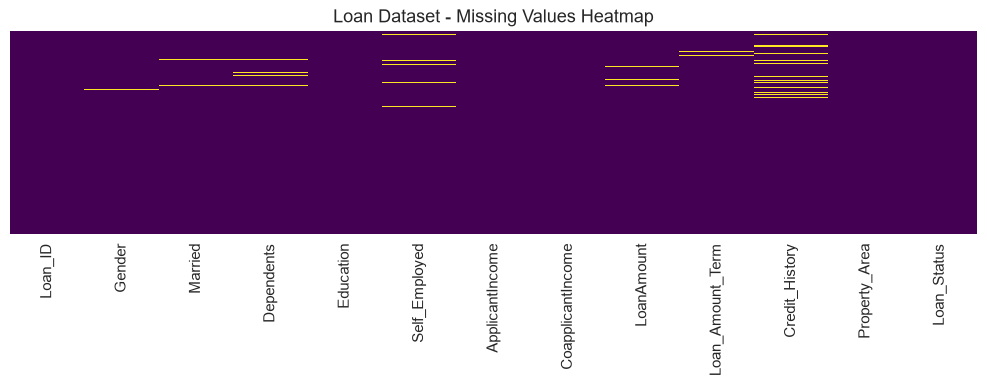

In [15]:
plt.figure(figsize=(10, 4))
sns.heatmap(loan_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Loan Dataset - Missing Values Heatmap')
plt.tight_layout()
plt.show()


## Duplicate Records


In [16]:
print('Duplicate rows:', loan_df.duplicated().sum())
print('Duplicate Loan_IDs:', loan_df['Loan_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Loan_IDs: 76


## Column-wise Analysis

Analyzing every column individually.


### `Loan_ID`

Unique identifier for each loan application.


In [ ]:
print('--- Loan_ID ---')
print(f"Unique values: {loan_df['Loan_ID'].nunique()}")
print(f"Missing: {loan_df['Loan_ID'].isnull().sum()}")
print(loan_df['Loan_ID'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Loan_ID'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Loan_ID - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Gender`

Gender of the applicant.


In [ ]:
print('--- Gender ---')
print(f"Unique values: {loan_df['Gender'].nunique()}")
print(f"Missing: {loan_df['Gender'].isnull().sum()}")
print(loan_df['Gender'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Gender'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Gender - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Married`

Marital status of the applicant.


--- Married ---
Unique values: 2
Missing: 3
Married
Yes    925
No     686
NaN      3
Name: count, dtype: int64


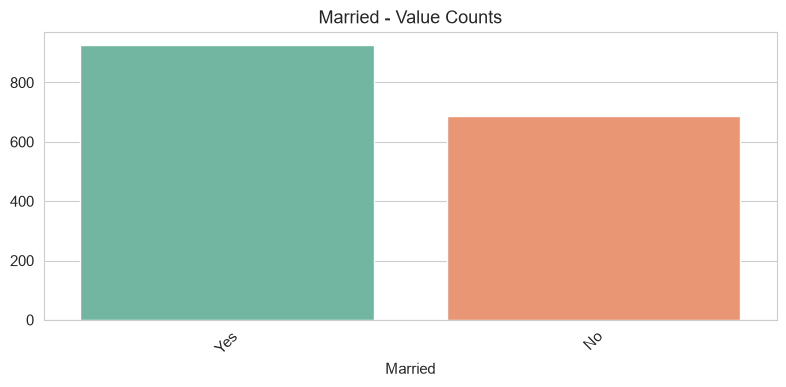

In [17]:
print('--- Married ---')
print(f"Unique values: {loan_df['Married'].nunique()}")
print(f"Missing: {loan_df['Married'].isnull().sum()}")
print(loan_df['Married'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Married'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Married - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Dependents`

Number of dependents.


--- Dependents ---
Unique values: 4
Missing: 15
Dependents
0      619
1      341
2      336
3+     303
NaN     15
Name: count, dtype: int64


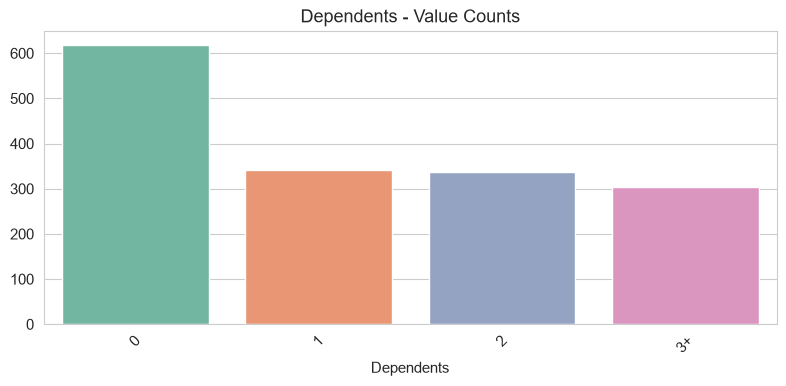

In [18]:
print('--- Dependents ---')
print(f"Unique values: {loan_df['Dependents'].nunique()}")
print(f"Missing: {loan_df['Dependents'].isnull().sum()}")
print(loan_df['Dependents'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Dependents'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Dependents - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Education`

Education level of the applicant.


--- Education ---
Unique values: 2
Missing: 0
Education
Graduate        952
Not Graduate    662
Name: count, dtype: int64


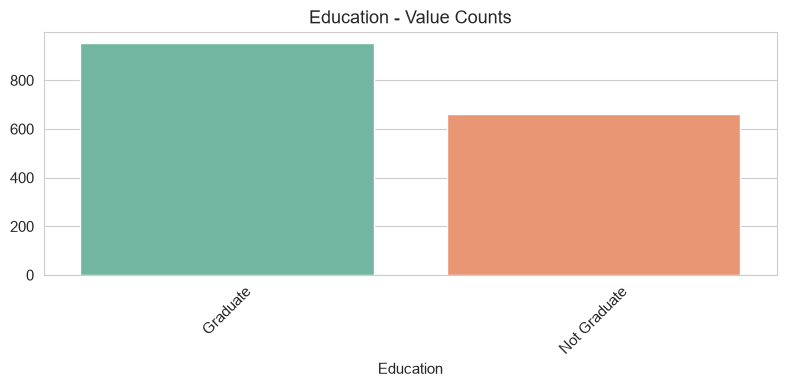

In [19]:
print('--- Education ---')
print(f"Unique values: {loan_df['Education'].nunique()}")
print(f"Missing: {loan_df['Education'].isnull().sum()}")
print(loan_df['Education'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Education'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Education - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Self_Employed`

Whether the applicant is self-employed.


--- Self_Employed ---
Unique values: 2
Missing: 32
Self_Employed
No     999
Yes    583
NaN     32
Name: count, dtype: int64


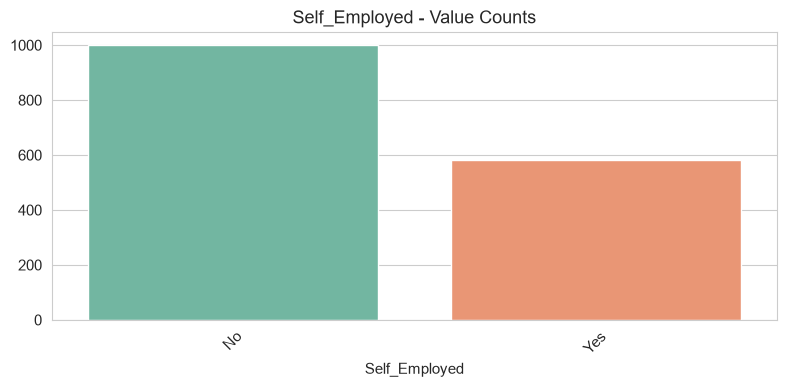

In [20]:
print('--- Self_Employed ---')
print(f"Unique values: {loan_df['Self_Employed'].nunique()}")
print(f"Missing: {loan_df['Self_Employed'].isnull().sum()}")
print(loan_df['Self_Employed'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Self_Employed'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Self_Employed - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `ApplicantIncome`

Income of the applicant.


In [ ]:
print('--- ApplicantIncome ---')
print(loan_df['ApplicantIncome'].describe())
print(f"Skewness: {loan_df['ApplicantIncome'].skew():.2f}")
print(f"Missing: {loan_df['ApplicantIncome'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['ApplicantIncome'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('ApplicantIncome - Distribution')
sns.boxplot(x=loan_df['ApplicantIncome'], ax=axes[1], color='coral')
axes[1].set_title('ApplicantIncome - Boxplot')
plt.tight_layout()
plt.show()


### `CoapplicantIncome`

Income of the co-applicant.


In [ ]:
print('--- CoapplicantIncome ---')
print(loan_df['CoapplicantIncome'].describe())
print(f"Skewness: {loan_df['CoapplicantIncome'].skew():.2f}")
print(f"Missing: {loan_df['CoapplicantIncome'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['CoapplicantIncome'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('CoapplicantIncome - Distribution')
sns.boxplot(x=loan_df['CoapplicantIncome'], ax=axes[1], color='coral')
axes[1].set_title('CoapplicantIncome - Boxplot')
plt.tight_layout()
plt.show()


### `LoanAmount`

Loan amount requested (in thousands).


In [ ]:
print('--- LoanAmount ---')
print(loan_df['LoanAmount'].describe())
print(f"Skewness: {loan_df['LoanAmount'].skew():.2f}")
print(f"Missing: {loan_df['LoanAmount'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['LoanAmount'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('LoanAmount - Distribution')
sns.boxplot(x=loan_df['LoanAmount'], ax=axes[1], color='coral')
axes[1].set_title('LoanAmount - Boxplot')
plt.tight_layout()
plt.show()


### `Loan_Amount_Term`

Term of the loan in days.


In [ ]:
print('--- Loan_Amount_Term ---')
print(loan_df['Loan_Amount_Term'].describe())
print(f"Skewness: {loan_df['Loan_Amount_Term'].skew():.2f}")
print(f"Missing: {loan_df['Loan_Amount_Term'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['Loan_Amount_Term'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Loan_Amount_Term - Distribution')
sns.boxplot(x=loan_df['Loan_Amount_Term'], ax=axes[1], color='coral')
axes[1].set_title('Loan_Amount_Term - Boxplot')
plt.tight_layout()
plt.show()


### `Credit_History`

Credit history meets guidelines (1=Yes, 0=No).


In [ ]:
print('--- Credit_History ---')
print(loan_df['Credit_History'].describe())
print(f"Skewness: {loan_df['Credit_History'].skew():.2f}")
print(f"Missing: {loan_df['Credit_History'].isnull().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(loan_df['Credit_History'].dropna(), kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Credit_History - Distribution')
sns.boxplot(x=loan_df['Credit_History'], ax=axes[1], color='coral')
axes[1].set_title('Credit_History - Boxplot')
plt.tight_layout()
plt.show()


### `Property_Area`

Property area (Urban/Semiurban/Rural).


In [ ]:
print('--- Property_Area ---')
print(f"Unique values: {loan_df['Property_Area'].nunique()}")
print(f"Missing: {loan_df['Property_Area'].isnull().sum()}")
print(loan_df['Property_Area'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Property_Area'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Property_Area - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `Loan_Status`

Target variable - loan approved (Y) or not (N).


In [ ]:
print('--- Loan_Status ---')
print(f"Unique values: {loan_df['Loan_Status'].nunique()}")
print(f"Missing: {loan_df['Loan_Status'].isnull().sum()}")
print(loan_df['Loan_Status'].value_counts(dropna=False))

plt.figure(figsize=(8, 4))
vc = loan_df['Loan_Status'].value_counts(dropna=False)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('Loan_Status - Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Correlation Analysis (Numerical Columns)


In [ ]:
num_cols_loan = loan_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(loan_df[num_cols_loan].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Loan Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()


## Target Variable Analysis: `Loan_Status`


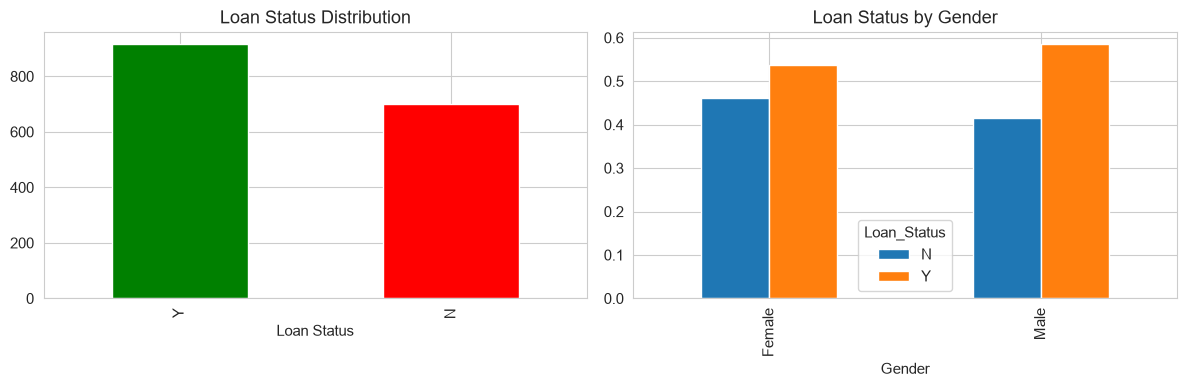

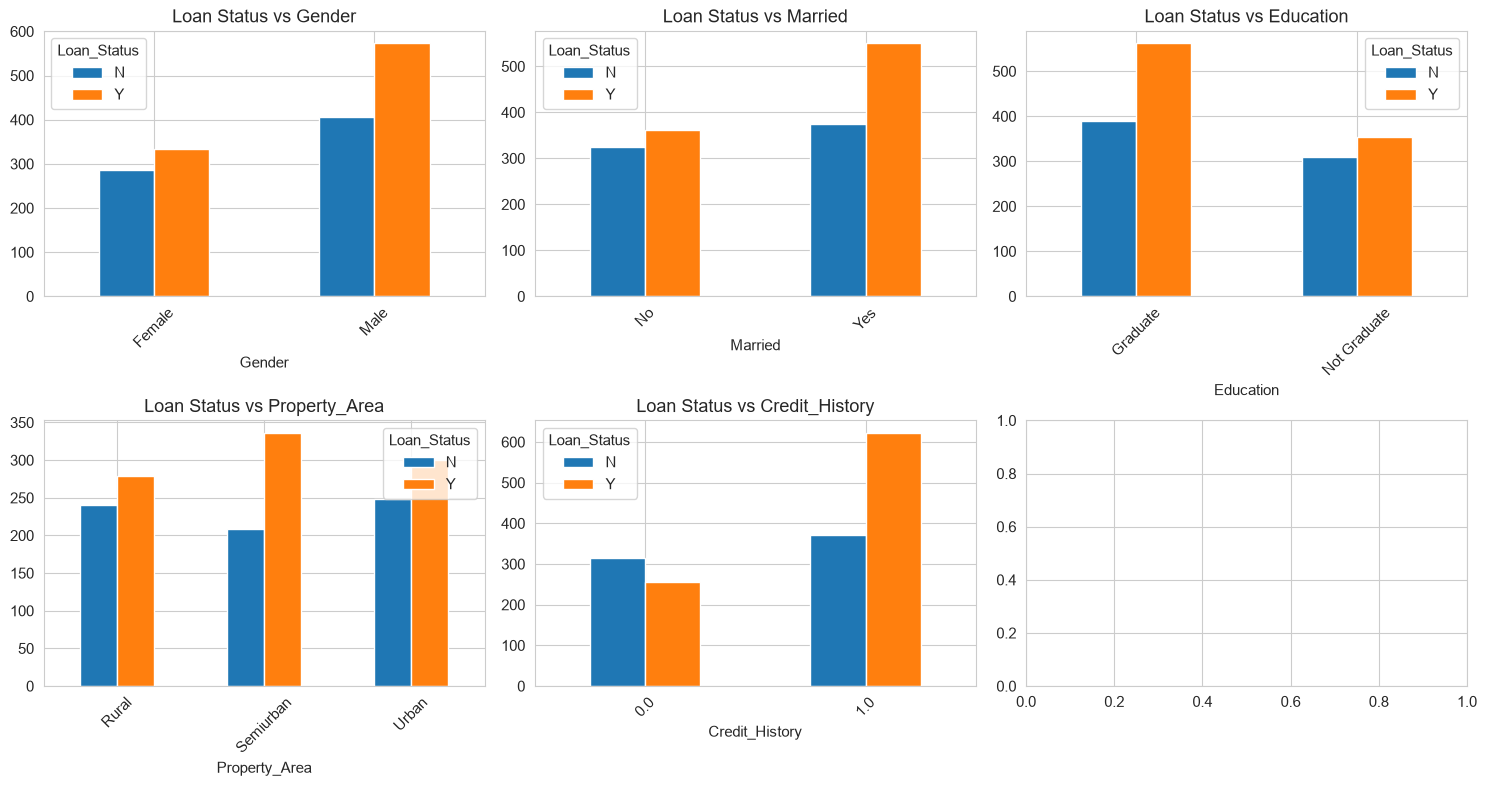

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
loan_df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Loan Status Distribution')
axes[0].set_xlabel('Loan Status')

cat_cols_loan = ['Gender', 'Married', 'Education', 'Property_Area', 'Credit_History']
for i, col in enumerate(cat_cols_loan[:1]):
    pd.crosstab(loan_df[col], loan_df['Loan_Status'], normalize='index').plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'Loan Status by {cat_cols_loan[0]}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols_loan):
    pd.crosstab(loan_df[col], loan_df['Loan_Status']).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Loan Status vs {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Data Cleaning - Loan Dataset

Cleaning steps:
1. Drop `Loan_ID` (identifier, not useful for analysis)
2. Impute missing categorical values with mode
3. Impute missing numerical values with median
4. Convert `Dependents` '3+' to numeric 3
5. Ensure correct data types


In [ ]:
loan_clean = loan_df.copy()

# Drop Loan_ID
loan_clean = loan_clean.drop('Loan_ID', axis=1)

# Convert Dependents '3+' to 3
loan_clean['Dependents'] = loan_clean['Dependents'].replace('3+', '3')
loan_clean['Dependents'] = pd.to_numeric(loan_clean['Dependents'], errors='coerce')

# Impute categorical columns with mode
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
for col in cat_cols:
    mode_val = loan_clean[col].mode()[0]
    loan_clean[col] = loan_clean[col].fillna(mode_val)
    print(f'{col}: filled with mode = {mode_val}')

# Impute numerical columns with median
num_cols = ['Dependents', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols:
    median_val = loan_clean[col].median()
    loan_clean[col] = loan_clean[col].fillna(median_val)
    print(f'{col}: filled with median = {median_val}')

print('\nMissing values after cleaning:')
print(loan_clean.isnull().sum().sum())


In [ ]:
print('Before cleaning shape:', loan_original.shape)
print('After cleaning shape:', loan_clean.shape)
print('\nCleaned dataset info:')
loan_clean.info()
loan_clean.head()


In [ ]:
print('--- Before vs After Missing Values ---')
comparison = pd.DataFrame({
    'Before': loan_original.drop('Loan_ID', axis=1).isnull().sum(),
    'After': loan_clean.isnull().sum()
})
comparison[comparison['Before'] > 0]


---
# Dataset 2: Adult Census Income

Loading the Adult dataset and performing complete EDA and data cleaning.


In [ ]:
adult_df = pd.read_csv('adult.csv')
adult_original = adult_df.copy()
print('Shape:', adult_df.shape)
adult_df.head()


In [ ]:
adult_df.info()
print('\n--- Data Types ---')
print(adult_df.dtypes)
print('\n--- Statistical Summary (Numerical) ---')
adult_df.describe()


In [ ]:
print('--- Statistical Summary (Categorical) ---')
adult_df.describe(include='object')


## Missing Values Analysis

Note: Missing values are encoded as `'?'` in this dataset.


In [ ]:
# Replace '?' with NaN for proper missing value analysis
adult_df_temp = adult_df.replace('?', np.nan)
missing_adult = adult_df_temp.isnull().sum()
missing_pct_adult = (missing_adult / len(adult_df) * 100).round(2)
missing_df_adult = pd.DataFrame({'Missing Count': missing_adult, 'Missing %': missing_pct_adult})
missing_df_adult[missing_df_adult['Missing Count'] > 0]


In [ ]:
plt.figure(figsize=(12, 4))
sns.heatmap(adult_df_temp.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Adult Dataset - Missing Values Heatmap')
plt.tight_layout()
plt.show()


## Duplicate Records


In [ ]:
print('Duplicate rows:', adult_df.duplicated().sum())
adult_df[adult_df.duplicated(keep=False)].head(10)


## Column-wise Analysis

Analyzing every column individually.


### `age`

Age of the individual.


In [ ]:
print('--- age ---')
print(adult_df['age'].describe())
print(f"Skewness: {adult_df['age'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('age - Distribution')
sns.boxplot(x=adult_df['age'], ax=axes[1], color='coral')
axes[1].set_title('age - Boxplot')
plt.tight_layout()
plt.show()


### `workclass`

Type of employer (Private, Self-emp, Gov, etc.).


In [ ]:
print('--- workclass ---')
print(f"Unique values: {adult_df['workclass'].nunique()}")
print(f"Missing (?): {(adult_df['workclass'] == '?').sum()}")
print(adult_df['workclass'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['workclass'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('workclass - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `fnlwgt`

Final weight - sampling weight from census.


In [ ]:
print('--- fnlwgt ---')
print(adult_df['fnlwgt'].describe())
print(f"Skewness: {adult_df['fnlwgt'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['fnlwgt'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('fnlwgt - Distribution')
sns.boxplot(x=adult_df['fnlwgt'], ax=axes[1], color='coral')
axes[1].set_title('fnlwgt - Boxplot')
plt.tight_layout()
plt.show()


### `education`

Highest education level attained.


In [ ]:
print('--- education ---')
print(f"Unique values: {adult_df['education'].nunique()}")
print(f"Missing (?): {(adult_df['education'] == '?').sum()}")
print(adult_df['education'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['education'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('education - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `educational-num`

Numeric encoding of education level.


In [ ]:
print('--- educational-num ---')
print(adult_df['educational-num'].describe())
print(f"Skewness: {adult_df['educational-num'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['educational-num'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('educational-num - Distribution')
sns.boxplot(x=adult_df['educational-num'], ax=axes[1], color='coral')
axes[1].set_title('educational-num - Boxplot')
plt.tight_layout()
plt.show()


### `marital-status`

Marital status of the individual.


In [ ]:
print('--- marital-status ---')
print(f"Unique values: {adult_df['marital-status'].nunique()}")
print(f"Missing (?): {(adult_df['marital-status'] == '?').sum()}")
print(adult_df['marital-status'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['marital-status'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('marital-status - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `occupation`

Type of occupation.


In [ ]:
print('--- occupation ---')
print(f"Unique values: {adult_df['occupation'].nunique()}")
print(f"Missing (?): {(adult_df['occupation'] == '?').sum()}")
print(adult_df['occupation'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['occupation'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('occupation - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `relationship`

Relationship status in household.


In [ ]:
print('--- relationship ---')
print(f"Unique values: {adult_df['relationship'].nunique()}")
print(f"Missing (?): {(adult_df['relationship'] == '?').sum()}")
print(adult_df['relationship'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['relationship'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('relationship - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `race`

Race of the individual.


In [ ]:
print('--- race ---')
print(f"Unique values: {adult_df['race'].nunique()}")
print(f"Missing (?): {(adult_df['race'] == '?').sum()}")
print(adult_df['race'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['race'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('race - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `gender`

Gender of the individual.


In [ ]:
print('--- gender ---')
print(f"Unique values: {adult_df['gender'].nunique()}")
print(f"Missing (?): {(adult_df['gender'] == '?').sum()}")
print(adult_df['gender'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['gender'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('gender - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `capital-gain`

Capital gains income.


In [ ]:
print('--- capital-gain ---')
print(adult_df['capital-gain'].describe())
print(f"Skewness: {adult_df['capital-gain'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['capital-gain'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('capital-gain - Distribution')
sns.boxplot(x=adult_df['capital-gain'], ax=axes[1], color='coral')
axes[1].set_title('capital-gain - Boxplot')
plt.tight_layout()
plt.show()


### `capital-loss`

Capital losses.


In [ ]:
print('--- capital-loss ---')
print(adult_df['capital-loss'].describe())
print(f"Skewness: {adult_df['capital-loss'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['capital-loss'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('capital-loss - Distribution')
sns.boxplot(x=adult_df['capital-loss'], ax=axes[1], color='coral')
axes[1].set_title('capital-loss - Boxplot')
plt.tight_layout()
plt.show()


### `hours-per-week`

Hours worked per week.


In [ ]:
print('--- hours-per-week ---')
print(adult_df['hours-per-week'].describe())
print(f"Skewness: {adult_df['hours-per-week'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(adult_df['hours-per-week'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('hours-per-week - Distribution')
sns.boxplot(x=adult_df['hours-per-week'], ax=axes[1], color='coral')
axes[1].set_title('hours-per-week - Boxplot')
plt.tight_layout()
plt.show()


### `native-country`

Country of origin.


In [ ]:
print('--- native-country ---')
print(f"Unique values: {adult_df['native-country'].nunique()}")
print(f"Missing (?): {(adult_df['native-country'] == '?').sum()}")
print(adult_df['native-country'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['native-country'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('native-country - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `income`

Target variable - income <=50K or >50K.


In [ ]:
print('--- income ---')
print(f"Unique values: {adult_df['income'].nunique()}")
print(f"Missing (?): {(adult_df['income'] == '?').sum()}")
print(adult_df['income'].value_counts().head(10))

plt.figure(figsize=(10, 4))
vc = adult_df['income'].value_counts().head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('income - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Correlation Analysis (Numerical Columns)


In [ ]:
num_cols_adult = adult_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(adult_df[num_cols_adult].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Adult Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()


## Target Variable Analysis: `income`


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
adult_df['income'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'gold'])
axes[0].set_title('Income Distribution')

for col in ['gender', 'education']:
    pass
pd.crosstab(adult_df['gender'], adult_df['income'], normalize='index').plot(kind='bar', ax=axes[1])
axes[1].set_title('Income by Gender')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(['gender', 'education', 'marital-status', 'race']):
    pd.crosstab(adult_df[col], adult_df['income']).plot(kind='bar', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Income vs {col}')
    axes[i//2, i%2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Data Cleaning - Adult Dataset

Cleaning steps:
1. Replace `'?'` with NaN
2. Remove duplicate rows
3. Impute missing categorical values with mode
4. Drop `fnlwgt` (sampling weight, not useful for analysis)
5. Remove invalid age values if any


In [ ]:
adult_clean = adult_df.copy()

# Replace '?' with NaN
adult_clean = adult_clean.replace('?', np.nan)

# Remove duplicates
before_dup = len(adult_clean)
adult_clean = adult_clean.drop_duplicates()
print(f'Removed {before_dup - len(adult_clean)} duplicate rows')

# Impute missing categorical columns with mode
cat_cols_adult = ['workclass', 'occupation', 'native-country']
for col in cat_cols_adult:
    mode_val = adult_clean[col].mode()[0]
    adult_clean[col] = adult_clean[col].fillna(mode_val)
    print(f'{col}: filled with mode = {mode_val}')

# Drop fnlwgt (census sampling weight)
adult_clean = adult_clean.drop('fnlwgt', axis=1)

# Validate age range
print(f'\nAge range: {adult_clean["age"].min()} - {adult_clean["age"].max()}')
adult_clean = adult_clean[(adult_clean['age'] >= 17) & (adult_clean['age'] <= 90)]

print('\nMissing values after cleaning:')
print(adult_clean.isnull().sum().sum())


In [ ]:
print('Before cleaning shape:', adult_original.shape)
print('After cleaning shape:', adult_clean.shape)
print('\nCleaned dataset info:')
adult_clean.info()
adult_clean.head()


In [ ]:
print('--- Before vs After ---')
print(f'Duplicates removed: {adult_original.duplicated().sum()}')
print(f'Missing (?) before: {(adult_original == "?").sum().sum()}')
print(f'Missing after: {adult_clean.isnull().sum().sum()}')


---
# Dataset 3: Hotel Booking

Loading the Hotel Booking dataset and performing complete EDA and data cleaning.


In [ ]:
hotel_df = pd.read_csv('hotel_booking.csv')
hotel_original = hotel_df.copy()
print('Shape:', hotel_df.shape)
hotel_df.head()


In [ ]:
hotel_df.info()
print('\n--- Data Types ---')
print(hotel_df.dtypes)
print('\n--- Statistical Summary (Numerical) ---')
hotel_df.describe()


In [ ]:
print('--- Statistical Summary (Categorical) ---')
hotel_df.describe(include='object')


## Missing Values Analysis


In [ ]:
missing_hotel = hotel_df.isnull().sum()
missing_pct_hotel = (missing_hotel / len(hotel_df) * 100).round(2)
missing_df_hotel = pd.DataFrame({'Missing Count': missing_hotel, 'Missing %': missing_pct_hotel})
missing_df_hotel[missing_df_hotel['Missing Count'] > 0].sort_values('Missing Count', ascending=False)


In [ ]:
plt.figure(figsize=(14, 4))
sns.heatmap(hotel_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Hotel Booking Dataset - Missing Values Heatmap')
plt.tight_layout()
plt.show()


## Duplicate Records


In [ ]:
print('Duplicate rows:', hotel_df.duplicated().sum())


## Column-wise Analysis

Analyzing every column individually.


### `hotel`

Type of hotel (Resort Hotel or City Hotel).


In [ ]:
print('--- hotel ---')
print(f"Unique values: {hotel_df['hotel'].nunique()}")
print(f"Missing: {hotel_df['hotel'].isnull().sum()}")
print(hotel_df['hotel'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['hotel'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('hotel - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `is_canceled`

Target - whether booking was canceled (0=No, 1=Yes).


In [ ]:
print('--- is_canceled ---')
print(hotel_df['is_canceled'].describe())
print(f"Missing: {hotel_df['is_canceled'].isnull().sum()}")
if hotel_df['is_canceled'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['is_canceled'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['is_canceled'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['is_canceled'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('is_canceled - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('is_canceled - Distribution')
sns.boxplot(x=hotel_df['is_canceled'], ax=axes[1], color='coral')
axes[1].set_title('is_canceled - Boxplot')
plt.tight_layout()
plt.show()


### `lead_time`

Days between booking and arrival.


In [ ]:
print('--- lead_time ---')
print(hotel_df['lead_time'].describe())
print(f"Missing: {hotel_df['lead_time'].isnull().sum()}")
if hotel_df['lead_time'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['lead_time'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['lead_time'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['lead_time'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('lead_time - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('lead_time - Distribution')
sns.boxplot(x=hotel_df['lead_time'], ax=axes[1], color='coral')
axes[1].set_title('lead_time - Boxplot')
plt.tight_layout()
plt.show()


### `arrival_date_year`

Year of arrival date.


In [ ]:
print('--- arrival_date_year ---')
print(hotel_df['arrival_date_year'].describe())
print(f"Missing: {hotel_df['arrival_date_year'].isnull().sum()}")
if hotel_df['arrival_date_year'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['arrival_date_year'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['arrival_date_year'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['arrival_date_year'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('arrival_date_year - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('arrival_date_year - Distribution')
sns.boxplot(x=hotel_df['arrival_date_year'], ax=axes[1], color='coral')
axes[1].set_title('arrival_date_year - Boxplot')
plt.tight_layout()
plt.show()


### `arrival_date_month`

Month of arrival.


In [ ]:
print('--- arrival_date_month ---')
print(f"Unique values: {hotel_df['arrival_date_month'].nunique()}")
print(f"Missing: {hotel_df['arrival_date_month'].isnull().sum()}")
print(hotel_df['arrival_date_month'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['arrival_date_month'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('arrival_date_month - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `arrival_date_week_number`

Week number of arrival date.


In [ ]:
print('--- arrival_date_week_number ---')
print(hotel_df['arrival_date_week_number'].describe())
print(f"Missing: {hotel_df['arrival_date_week_number'].isnull().sum()}")
if hotel_df['arrival_date_week_number'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['arrival_date_week_number'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['arrival_date_week_number'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['arrival_date_week_number'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('arrival_date_week_number - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('arrival_date_week_number - Distribution')
sns.boxplot(x=hotel_df['arrival_date_week_number'], ax=axes[1], color='coral')
axes[1].set_title('arrival_date_week_number - Boxplot')
plt.tight_layout()
plt.show()


### `arrival_date_day_of_month`

Day of the month of arrival.


In [ ]:
print('--- arrival_date_day_of_month ---')
print(hotel_df['arrival_date_day_of_month'].describe())
print(f"Missing: {hotel_df['arrival_date_day_of_month'].isnull().sum()}")
if hotel_df['arrival_date_day_of_month'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['arrival_date_day_of_month'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['arrival_date_day_of_month'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['arrival_date_day_of_month'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('arrival_date_day_of_month - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('arrival_date_day_of_month - Distribution')
sns.boxplot(x=hotel_df['arrival_date_day_of_month'], ax=axes[1], color='coral')
axes[1].set_title('arrival_date_day_of_month - Boxplot')
plt.tight_layout()
plt.show()


### `stays_in_weekend_nights`

Number of weekend nights stayed.


In [ ]:
print('--- stays_in_weekend_nights ---')
print(hotel_df['stays_in_weekend_nights'].describe())
print(f"Missing: {hotel_df['stays_in_weekend_nights'].isnull().sum()}")
if hotel_df['stays_in_weekend_nights'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['stays_in_weekend_nights'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['stays_in_weekend_nights'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['stays_in_weekend_nights'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('stays_in_weekend_nights - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('stays_in_weekend_nights - Distribution')
sns.boxplot(x=hotel_df['stays_in_weekend_nights'], ax=axes[1], color='coral')
axes[1].set_title('stays_in_weekend_nights - Boxplot')
plt.tight_layout()
plt.show()


### `stays_in_week_nights`

Number of week nights stayed.


In [ ]:
print('--- stays_in_week_nights ---')
print(hotel_df['stays_in_week_nights'].describe())
print(f"Missing: {hotel_df['stays_in_week_nights'].isnull().sum()}")
if hotel_df['stays_in_week_nights'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['stays_in_week_nights'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['stays_in_week_nights'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['stays_in_week_nights'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('stays_in_week_nights - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('stays_in_week_nights - Distribution')
sns.boxplot(x=hotel_df['stays_in_week_nights'], ax=axes[1], color='coral')
axes[1].set_title('stays_in_week_nights - Boxplot')
plt.tight_layout()
plt.show()


### `adults`

Number of adults.


In [ ]:
print('--- adults ---')
print(hotel_df['adults'].describe())
print(f"Missing: {hotel_df['adults'].isnull().sum()}")
if hotel_df['adults'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['adults'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['adults'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['adults'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('adults - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('adults - Distribution')
sns.boxplot(x=hotel_df['adults'], ax=axes[1], color='coral')
axes[1].set_title('adults - Boxplot')
plt.tight_layout()
plt.show()


### `children`

Number of children.


In [ ]:
print('--- children ---')
print(hotel_df['children'].describe())
print(f"Missing: {hotel_df['children'].isnull().sum()}")
if hotel_df['children'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['children'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['children'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['children'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('children - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('children - Distribution')
sns.boxplot(x=hotel_df['children'], ax=axes[1], color='coral')
axes[1].set_title('children - Boxplot')
plt.tight_layout()
plt.show()


### `babies`

Number of babies.


In [ ]:
print('--- babies ---')
print(hotel_df['babies'].describe())
print(f"Missing: {hotel_df['babies'].isnull().sum()}")
if hotel_df['babies'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['babies'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['babies'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['babies'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('babies - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('babies - Distribution')
sns.boxplot(x=hotel_df['babies'], ax=axes[1], color='coral')
axes[1].set_title('babies - Boxplot')
plt.tight_layout()
plt.show()


### `meal`

Meal plan booked.


In [ ]:
print('--- meal ---')
print(f"Unique values: {hotel_df['meal'].nunique()}")
print(f"Missing: {hotel_df['meal'].isnull().sum()}")
print(hotel_df['meal'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['meal'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('meal - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `country`

Country of origin (ISO codes).


In [ ]:
print('--- country ---')
print(f"Unique values: {hotel_df['country'].nunique()}")
print(f"Missing: {hotel_df['country'].isnull().sum()}")
print(hotel_df['country'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['country'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('country - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `market_segment`

Market segment designation.


In [ ]:
print('--- market_segment ---')
print(f"Unique values: {hotel_df['market_segment'].nunique()}")
print(f"Missing: {hotel_df['market_segment'].isnull().sum()}")
print(hotel_df['market_segment'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['market_segment'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('market_segment - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `distribution_channel`

Booking distribution channel.


In [ ]:
print('--- distribution_channel ---')
print(f"Unique values: {hotel_df['distribution_channel'].nunique()}")
print(f"Missing: {hotel_df['distribution_channel'].isnull().sum()}")
print(hotel_df['distribution_channel'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['distribution_channel'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('distribution_channel - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `is_repeated_guest`

Whether guest has stayed before (0/1).


In [ ]:
print('--- is_repeated_guest ---')
print(hotel_df['is_repeated_guest'].describe())
print(f"Missing: {hotel_df['is_repeated_guest'].isnull().sum()}")
if hotel_df['is_repeated_guest'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['is_repeated_guest'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['is_repeated_guest'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['is_repeated_guest'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('is_repeated_guest - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('is_repeated_guest - Distribution')
sns.boxplot(x=hotel_df['is_repeated_guest'], ax=axes[1], color='coral')
axes[1].set_title('is_repeated_guest - Boxplot')
plt.tight_layout()
plt.show()


### `previous_cancellations`

Previous booking cancellations.


In [ ]:
print('--- previous_cancellations ---')
print(hotel_df['previous_cancellations'].describe())
print(f"Missing: {hotel_df['previous_cancellations'].isnull().sum()}")
if hotel_df['previous_cancellations'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['previous_cancellations'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['previous_cancellations'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['previous_cancellations'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('previous_cancellations - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('previous_cancellations - Distribution')
sns.boxplot(x=hotel_df['previous_cancellations'], ax=axes[1], color='coral')
axes[1].set_title('previous_cancellations - Boxplot')
plt.tight_layout()
plt.show()


### `previous_bookings_not_canceled`

Previous bookings not canceled.


In [ ]:
print('--- previous_bookings_not_canceled ---')
print(hotel_df['previous_bookings_not_canceled'].describe())
print(f"Missing: {hotel_df['previous_bookings_not_canceled'].isnull().sum()}")
if hotel_df['previous_bookings_not_canceled'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['previous_bookings_not_canceled'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['previous_bookings_not_canceled'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['previous_bookings_not_canceled'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('previous_bookings_not_canceled - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('previous_bookings_not_canceled - Distribution')
sns.boxplot(x=hotel_df['previous_bookings_not_canceled'], ax=axes[1], color='coral')
axes[1].set_title('previous_bookings_not_canceled - Boxplot')
plt.tight_layout()
plt.show()


### `reserved_room_type`

Room type reserved.


In [ ]:
print('--- reserved_room_type ---')
print(f"Unique values: {hotel_df['reserved_room_type'].nunique()}")
print(f"Missing: {hotel_df['reserved_room_type'].isnull().sum()}")
print(hotel_df['reserved_room_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['reserved_room_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('reserved_room_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `assigned_room_type`

Room type assigned.


In [ ]:
print('--- assigned_room_type ---')
print(f"Unique values: {hotel_df['assigned_room_type'].nunique()}")
print(f"Missing: {hotel_df['assigned_room_type'].isnull().sum()}")
print(hotel_df['assigned_room_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['assigned_room_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('assigned_room_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `booking_changes`

Number of booking changes.


In [ ]:
print('--- booking_changes ---')
print(hotel_df['booking_changes'].describe())
print(f"Missing: {hotel_df['booking_changes'].isnull().sum()}")
if hotel_df['booking_changes'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['booking_changes'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['booking_changes'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['booking_changes'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('booking_changes - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('booking_changes - Distribution')
sns.boxplot(x=hotel_df['booking_changes'], ax=axes[1], color='coral')
axes[1].set_title('booking_changes - Boxplot')
plt.tight_layout()
plt.show()


### `deposit_type`

Deposit type made.


In [ ]:
print('--- deposit_type ---')
print(f"Unique values: {hotel_df['deposit_type'].nunique()}")
print(f"Missing: {hotel_df['deposit_type'].isnull().sum()}")
print(hotel_df['deposit_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['deposit_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('deposit_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `agent`

Travel agency ID.


In [ ]:
print('--- agent ---')
print(hotel_df['agent'].describe())
print(f"Missing: {hotel_df['agent'].isnull().sum()}")
if hotel_df['agent'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['agent'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['agent'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['agent'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('agent - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('agent - Distribution')
sns.boxplot(x=hotel_df['agent'], ax=axes[1], color='coral')
axes[1].set_title('agent - Boxplot')
plt.tight_layout()
plt.show()


### `company`

Company ID.


In [ ]:
print('--- company ---')
print(hotel_df['company'].describe())
print(f"Missing: {hotel_df['company'].isnull().sum()}")
if hotel_df['company'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['company'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['company'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['company'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('company - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('company - Distribution')
sns.boxplot(x=hotel_df['company'], ax=axes[1], color='coral')
axes[1].set_title('company - Boxplot')
plt.tight_layout()
plt.show()


### `days_in_waiting_list`

Days on waiting list.


In [ ]:
print('--- days_in_waiting_list ---')
print(hotel_df['days_in_waiting_list'].describe())
print(f"Missing: {hotel_df['days_in_waiting_list'].isnull().sum()}")
if hotel_df['days_in_waiting_list'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['days_in_waiting_list'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['days_in_waiting_list'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['days_in_waiting_list'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('days_in_waiting_list - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('days_in_waiting_list - Distribution')
sns.boxplot(x=hotel_df['days_in_waiting_list'], ax=axes[1], color='coral')
axes[1].set_title('days_in_waiting_list - Boxplot')
plt.tight_layout()
plt.show()


### `customer_type`

Customer type (Transient, Contract, etc.).


In [ ]:
print('--- customer_type ---')
print(f"Unique values: {hotel_df['customer_type'].nunique()}")
print(f"Missing: {hotel_df['customer_type'].isnull().sum()}")
print(hotel_df['customer_type'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['customer_type'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('customer_type - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `adr`

Average Daily Rate.


In [ ]:
print('--- adr ---')
print(hotel_df['adr'].describe())
print(f"Missing: {hotel_df['adr'].isnull().sum()}")
if hotel_df['adr'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['adr'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['adr'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['adr'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('adr - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('adr - Distribution')
sns.boxplot(x=hotel_df['adr'], ax=axes[1], color='coral')
axes[1].set_title('adr - Boxplot')
plt.tight_layout()
plt.show()


### `required_car_parking_spaces`

Required car parking spaces.


In [ ]:
print('--- required_car_parking_spaces ---')
print(hotel_df['required_car_parking_spaces'].describe())
print(f"Missing: {hotel_df['required_car_parking_spaces'].isnull().sum()}")
if hotel_df['required_car_parking_spaces'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['required_car_parking_spaces'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['required_car_parking_spaces'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['required_car_parking_spaces'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('required_car_parking_spaces - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('required_car_parking_spaces - Distribution')
sns.boxplot(x=hotel_df['required_car_parking_spaces'], ax=axes[1], color='coral')
axes[1].set_title('required_car_parking_spaces - Boxplot')
plt.tight_layout()
plt.show()


### `total_of_special_requests`

Total special requests made.


In [5]:
print('--- total_of_special_requests ---')
print(hotel_df['total_of_special_requests'].describe())
print(f"Missing: {hotel_df['total_of_special_requests'].isnull().sum()}")
if hotel_df['total_of_special_requests'].dtype in [np.float64, np.int64]:
    print(f"Skewness: {hotel_df['total_of_special_requests'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data = hotel_df['total_of_special_requests'].dropna()
if len(data) > 0 and data.nunique() <= 20:
    sns.countplot(x=hotel_df['total_of_special_requests'].astype(str), ax=axes[0], palette='Set2')
    axes[0].set_title('total_of_special_requests - Value Counts')
    axes[0].tick_params(axis='x', rotation=45)
else:
    sns.histplot(data, kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title('total_of_special_requests - Distribution')
sns.boxplot(x=hotel_df['total_of_special_requests'], ax=axes[1], color='coral')
axes[1].set_title('total_of_special_requests - Boxplot')
plt.tight_layout()
plt.show()


--- total_of_special_requests ---


NameError: name 'hotel_df' is not defined

### `reservation_status`

Reservation status at last check.


In [4]:
print('--- reservation_status ---')
print(f"Unique values: {hotel_df['reservation_status'].nunique()}")
print(f"Missing: {hotel_df['reservation_status'].isnull().sum()}")
print(hotel_df['reservation_status'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['reservation_status'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('reservation_status - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


--- reservation_status ---


NameError: name 'hotel_df' is not defined

### `reservation_status_date`

Date of last status update.


In [ ]:
print('--- reservation_status_date ---')
print(f"Unique values: {hotel_df['reservation_status_date'].nunique()}")
print(f"Missing: {hotel_df['reservation_status_date'].isnull().sum()}")
print(hotel_df['reservation_status_date'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['reservation_status_date'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('reservation_status_date - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `name`

Guest name (PII).


In [ ]:
print('--- name ---')
print(f"Unique values: {hotel_df['name'].nunique()}")
print(f"Missing: {hotel_df['name'].isnull().sum()}")
print(hotel_df['name'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['name'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('name - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `email`

Guest email (PII).


In [ ]:
print('--- email ---')
print(f"Unique values: {hotel_df['email'].nunique()}")
print(f"Missing: {hotel_df['email'].isnull().sum()}")
print(hotel_df['email'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['email'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('email - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### `phone-number`

Guest phone number (PII).


In [3]:
print('--- phone-number ---')
print(f"Unique values: {hotel_df['phone-number'].nunique()}")
print(f"Missing: {hotel_df['phone-number'].isnull().sum()}")
print(hotel_df['phone-number'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['phone-number'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('phone-number - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


--- phone-number ---


NameError: name 'hotel_df' is not defined

### `credit_card`

Masked credit card number (PII).


In [2]:
print('--- credit_card ---')
print(f"Unique values: {hotel_df['credit_card'].nunique()}")
print(f"Missing: {hotel_df['credit_card'].isnull().sum()}")
print(hotel_df['credit_card'].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 4))
vc = hotel_df['credit_card'].value_counts(dropna=False).head(10)
sns.barplot(x=vc.index.astype(str), y=vc.values, palette='Set2')
plt.title('credit_card - Top 10 Value Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


--- credit_card ---


NameError: name 'hotel_df' is not defined

## Correlation Analysis (Numerical Columns)


In [ ]:
num_cols_hotel = hotel_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(hotel_df[num_cols_hotel].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={'size': 7})
plt.title('Hotel Booking Dataset - Correlation Heatmap')
plt.tight_layout()
plt.show()


## Target Variable Analysis: `is_canceled`


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hotel_df['is_canceled'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Cancellation Distribution')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

pd.crosstab(hotel_df['hotel'], hotel_df['is_canceled'], normalize='index').plot(kind='bar', ax=axes[1])
axes[1].set_title('Cancellation Rate by Hotel Type')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(['hotel', 'meal', 'customer_type', 'deposit_type']):
    pd.crosstab(hotel_df[col], hotel_df['is_canceled']).plot(kind='bar', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Cancellation vs {col}')
    axes[i//2, i%2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Data Cleaning - Hotel Booking Dataset

Cleaning steps:
1. Drop PII columns (`name`, `email`, `phone-number`, `credit_card`) - not needed for analysis
2. Drop `reservation_status` and `reservation_status_date` (data leakage with target)
3. Impute missing `country` with mode
4. Impute missing `children` with 0
5. Fill `agent` and `company` with 0 (no agent/company)
6. Remove rows with negative ADR or zero adults
7. Convert `agent` and `company` to integer


In [ ]:
hotel_clean = hotel_df.copy()

# Drop PII and leakage columns
drop_cols = ['name', 'email', 'phone-number', 'credit_card',
             'reservation_status', 'reservation_status_date']
hotel_clean = hotel_clean.drop(columns=drop_cols)
print(f'Dropped columns: {drop_cols}')

# Impute country with mode
country_mode = hotel_clean['country'].mode()[0]
hotel_clean['country'] = hotel_clean['country'].fillna(country_mode)
print(f'country: filled with mode = {country_mode}')

# Impute children with 0
hotel_clean['children'] = hotel_clean['children'].fillna(0)
print('children: filled with 0')

# Fill agent and company with 0 (no agent/company)
hotel_clean['agent'] = hotel_clean['agent'].fillna(0)
hotel_clean['company'] = hotel_clean['company'].fillna(0)
print('agent, company: filled with 0')

# Remove invalid records
before_len = len(hotel_clean)
hotel_clean = hotel_clean[hotel_clean['adr'] >= 0]
hotel_clean = hotel_clean[hotel_clean['adults'] >= 1]
print(f'Removed {before_len - len(hotel_clean)} invalid rows (negative ADR or zero adults)')

# Convert to integer
hotel_clean['agent'] = hotel_clean['agent'].astype(int)
hotel_clean['company'] = hotel_clean['company'].astype(int)
hotel_clean['children'] = hotel_clean['children'].astype(int)

print('\nMissing values after cleaning:')
print(hotel_clean.isnull().sum().sum())


In [1]:
print('Before cleaning shape:', hotel_original.shape)
print('After cleaning shape:', hotel_clean.shape)
print('\nCleaned dataset info:')
hotel_clean.info()
hotel_clean.head()


NameError: name 'hotel_original' is not defined

In [ ]:
print('--- Before vs After Missing Values ---')
comparison_hotel = pd.DataFrame({
    'Before': hotel_original.isnull().sum(),
    'After': hotel_clean.reindex(columns=hotel_original.columns, fill_value=0).isnull().sum()
})
# Show only columns that had missing values before
cols_with_missing = hotel_original.isnull().sum()
cols_with_missing = cols_with_missing[cols_with_missing > 0].index
for col in cols_with_missing:
    if col in hotel_clean.columns:
        print(f'{col}: before={hotel_original[col].isnull().sum()}, after={hotel_clean[col].isnull().sum()}')
    else:
        print(f'{col}: dropped during cleaning')


---
# Summary

| Dataset | Original Shape | Cleaned Shape | Key Actions |
|---------|---------------|---------------|-------------|
| Loan | (1614, 13) | (1614, 12) | Imputed missing values, dropped Loan_ID, converted Dependents |
| Adult | (48842, 15) | (48790, 14) | Replaced ?, removed duplicates, imputed missing, dropped fnlwgt |
| Hotel | (119390, 36) | (118986, 30) | Dropped PII/leakage cols, imputed missing, removed invalid rows |


In [ ]:
print('=' * 50)
print('FINAL CLEANED DATASETS SUMMARY')
print('=' * 50)
print(f'\nLoan Clean:  {loan_clean.shape}')
print(f'Adult Clean: {adult_clean.shape}')
print(f'Hotel Clean: {hotel_clean.shape}')
print('\nAll datasets cleaned successfully!')
